<a href="https://colab.research.google.com/github/kuxx12257/machine_learnng_COOKBOOK/blob/branch1/co2emission_mullinreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
%matplotlib inline
from sklearn import linear_model
from sklearn.metrics import r2_score

In [2]:
!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv

--2026-02-05 10:19:08--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.03s   

2026-02-05 10:19:08 (2.19 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [4]:
df=pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
cdf=df[["CO2EMISSIONS","FUELCONSUMPTION_COMB","CYLINDERS","ENGINESIZE"]]
cdf.head()

,CO2EMISSIONS,FUELCONSUMPTION_COMB,CYLINDERS,ENGINESIZE
0,196,8.5,4,2.0
1,221,9.6,4,2.4
2,136,5.9,4,1.5
3,255,11.1,6,3.5
4,244,10.6,6,3.5


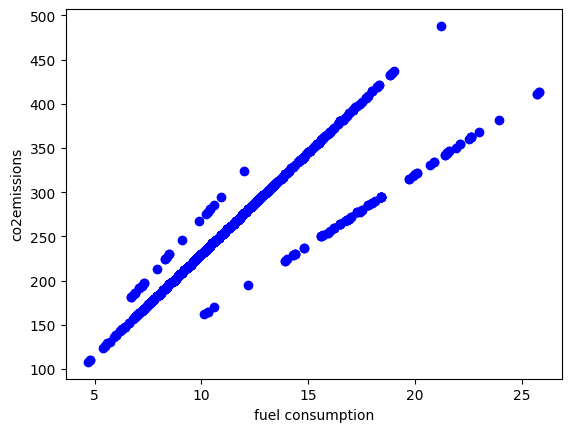

In [6]:
plt.scatter(cdf.FUELCONSUMPTION_COMB,cdf.CO2EMISSIONS,color="blue")
plt.xlabel("fuel consumption")
plt.ylabel("co2emissions")

plt.show()

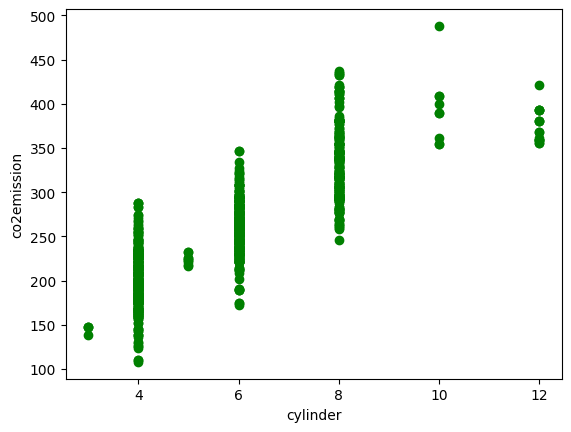

In [7]:
plt.scatter(cdf.CYLINDERS,cdf.CO2EMISSIONS,color="green")
plt.xlabel("cylinder")
plt.ylabel("co2emission")
plt.show()

In [10]:
#creating the train and test dataset

msk=np.random.rand(len(df))<0.85
train=cdf[msk]
test=cdf[~msk]
print(train)
print(test)


      CO2EMISSIONS  FUELCONSUMPTION_COMB  CYLINDERS  ENGINESIZE
0              196                   8.5          4         2.0
1              221                   9.6          4         2.4
2              136                   5.9          4         1.5
3              255                  11.1          6         3.5
4              244                  10.6          6         3.5
...            ...                   ...        ...         ...
1062           271                  11.8          6         3.0
1063           264                  11.5          6         3.2
1064           271                  11.8          6         3.0
1065           260                  11.3          6         3.2
1066           294                  12.8          6         3.2

[904 rows x 4 columns]
      CO2EMISSIONS  FUELCONSUMPTION_COMB  CYLINDERS  ENGINESIZE
10             225                   9.8          4         2.4
15             354                  15.4          8         4.7
26             2

In [14]:
#CREATING THE ARRAYS
train_x=np.asanyarray(train[["FUELCONSUMPTION_COMB","CYLINDERS","ENGINESIZE"]])
train_y=np.asanyarray(train[["CO2EMISSIONS"]])
test_x=np.asanyarray(test[["FUELCONSUMPTION_COMB","CYLINDERS","ENGINESIZE"]])
test_y=np.asanyarray(test[["CO2EMISSIONS"]])

In [17]:
regr=linear_model.LinearRegression()
regr.fit(train_x,train_y)
print("coefficinets:",regr.coef_)
print("intercept",regr.intercept_)

coefficinets: [[9.83214146 7.97311546 9.78647369]]
intercept [63.69366643]


In [18]:
test_Y=regr.predict(test_x)
print("score:",r2_score(test_Y,test_y))

score: 0.85756357305771
